# EBM - Equilibrium Propagation (EP) on MNIST 14x14

* Downsampling MNIST for faster runs
* Equilibrium Propagation exploration:
    * Find hyperparameters which achieve reasonable accuracy
    * Grid search hyperparameters to understand relationships
    * Use meta learning to find optimal hyperparameters
    * Evaluate on classIL forgetting problem - incrementally learn each class

In [23]:
import pandas as pd
import time

import torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


### Data load and preprocessing

In [2]:
#  imports and data (14×14 for experiments, 28×28 kept for the downsampling view)
tf28 = T.Compose([T.ToTensor()])                                      # original 28×28, [0,1]
tf14 = T.Compose([T.Resize((14, 14), antialias=True), T.ToTensor()])  # downsampled 14×14, [0,1]
train28  = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf28)
train_14 = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf14)
test_14  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf14)

def _stack(dataset, idx):
    return torch.stack([dataset[i][0] for i in idx]).to(device)

print("14×14 sample shape:", tuple(train_14[0][0].shape))   # expect (1, 14, 14) -> 196 inputs

14×14 sample shape: (1, 14, 14)


### Downsmpling quality control

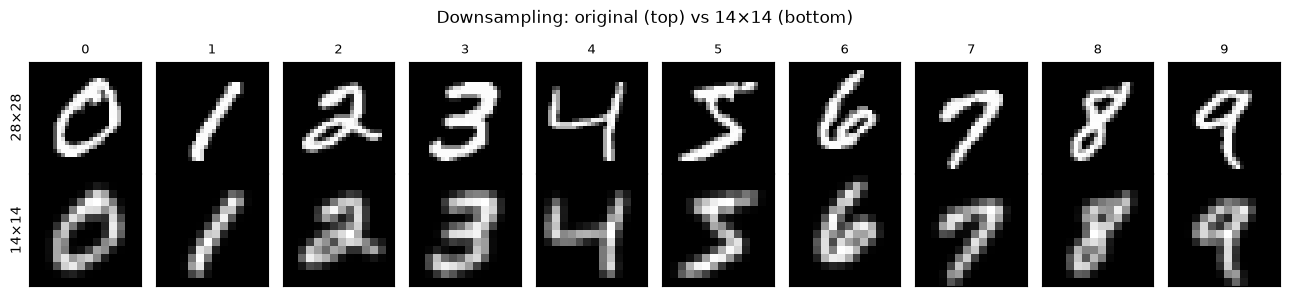

In [3]:
# pre/post downsampling, one example per digit
ex = [(train28.targets == d).nonzero(as_tuple=True)[0][0].item() for d in range(10)]  # first of each digit
fig, axes = plt.subplots(2, 10, figsize=(13, 3))
for j, idx in enumerate(ex):
    axes[0, j].imshow(train28[idx][0].squeeze(),  cmap="gray"); axes[0, j].set_title(str(train28[idx][1]), fontsize=9)
    axes[1, j].imshow(train_14[idx][0].squeeze(), cmap="gray")
    for r in (0, 1): axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
axes[0, 0].set_ylabel("28×28"); axes[1, 0].set_ylabel("14×14")
fig.suptitle("Downsampling: original (top) vs 14×14 (bottom)")
plt.tight_layout(); plt.show()

### Train with backprop to find an accuracy "ceiling"

* Single layer, 64 hidden units, 10 outputs, ReLU, SGD optimiser, Cross entropy loss

units= 16 | acc=92.0% | runtime=109.6s
units= 32 | acc=92.2% | runtime=127.2s
units= 64 | acc=92.5% | runtime=145.1s
units=128 | acc=92.7% | runtime=146.8s
units=256 | acc=92.8% | runtime=149.1s


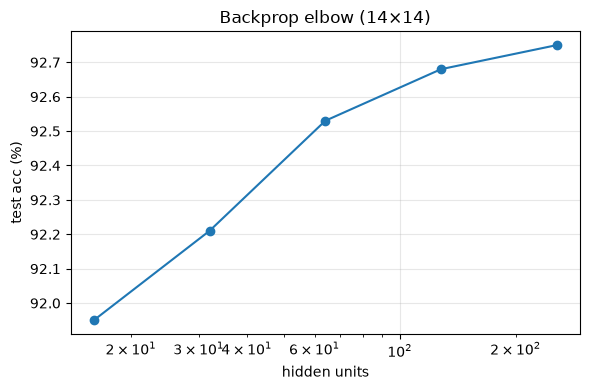

In [4]:
def make_mlp(hidden=(64,), in_dim=196, out_dim=10):
    layers, prev = [nn.Flatten()], in_dim
    for h in hidden: layers += [nn.Linear(prev, h), nn.ReLU()]; prev = h
    layers += [nn.Linear(prev, out_dim)]
    return nn.Sequential(*layers)

def fit(model, loader, epochs=5, lr=0.1):
    model.to(device).train(); opt = torch.optim.SGD(model.parameters(), lr=lr); lf = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); lf(model(x), y).backward(); opt.step()
    return model

@torch.no_grad()
def evaluate(model, loader):
    model.to(device).eval(); c = t = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        c += (model(x).argmax(1) == y).sum().item(); t += y.size(0)
    return c / t

elbow = {}
for h in [16, 32, 64, 128, 256]:
    t0 = time.time()
    torch.manual_seed(0); m = make_mlp(hidden=(h,), in_dim=196)
    fit(m, DataLoader(train_14, batch_size=128, shuffle=True), epochs=5)
    elbow[h] = evaluate(m, DataLoader(test_14, batch_size=256)) * 100
    runtime = time.time() - t0
    print(f"units={h:3d} | acc={elbow[h]:.1f}% | runtime={runtime:.1f}s")

BACKPROP_ACC = elbow[64]                                   # the EBM's target line (matched width)
plt.figure(figsize=(6, 4))
plt.plot(list(elbow), list(elbow.values()), "o-"); plt.xscale("log")
plt.xlabel("hidden units"); plt.ylabel("test acc (%)"); plt.title("Backprop elbow (14×14)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Implement EP algorithm

* Single layer, 64 hidden units, 10 outputs, ReLU?, SGD optimiser
* Run default hidden=64, lr=0.05, beta=0.5, steps=100, dt=0.5, tol=1e-2, epochs=3
* Run validation every 20 (should this be all?)
* Early stopping with patience 20

### Hyperparameter explorations

* Low 45% accuracy achieved. Saturation increases as it drops off back to 20%
* 120 appears not enough for convergence (assumption). Increase to 300
* Better convergence should allow higher learning rate, increase from 0.05 > 0.1

* Results notably better. Accuracy up to 89%, not converged yet, and saturation still very low.

### Logging changes

* Dynamic steps - early stopping when equalisation achieves tolerance
* Higher frequency logging
* Even out logging (log eveenly sized)
* Increase max steps to 1000 and epochs to 5, wide net to catch convergence.
* Increase dt from 0.1 > 0.2, larger steps should allow settling faster. At dt=0.1, nudge phase was hitting 1000 steps before settling, free phase was incresasing from 200-300.

epoch 0 batch    9 (step    10,    8s): train  10.9% | val  15.1% | best  15.1% | sat  0.0% | N-free 304.7, N-nudge 71.3
epoch 0 batch   19 (step    20,   15s): train  17.2% | val  25.9% | best  25.9% | sat  0.0% | N-free 266.4, N-nudge 76.7
epoch 0 batch   29 (step    30,   21s): train  40.6% | val  37.5% | best  37.5% | sat  0.0% | N-free 259.7, N-nudge 74.5
epoch 0 batch   39 (step    40,   28s): train  51.6% | val  49.4% | best  49.4% | sat  0.0% | N-free 262.8, N-nudge 73.1
epoch 0 batch   49 (step    50,   36s): train  42.2% | val  53.0% | best  53.0% | sat  0.0% | N-free 272.3, N-nudge 70.7
epoch 0 batch   59 (step    60,   42s): train  57.8% | val  50.4% | best  53.0% | sat  0.0% | N-free 274.6, N-nudge 70.5
epoch 0 batch   69 (step    70,   48s): train  48.4% | val  66.3% | best  66.3% | sat  0.0% | N-free 278.2, N-nudge 70.6
epoch 0 batch   79 (step    80,   55s): train  54.7% | val  45.8% | best  66.3% | sat  0.0% | N-free 286.2, N-nudge 69.9
epoch 0 batch   89 (step    90, 

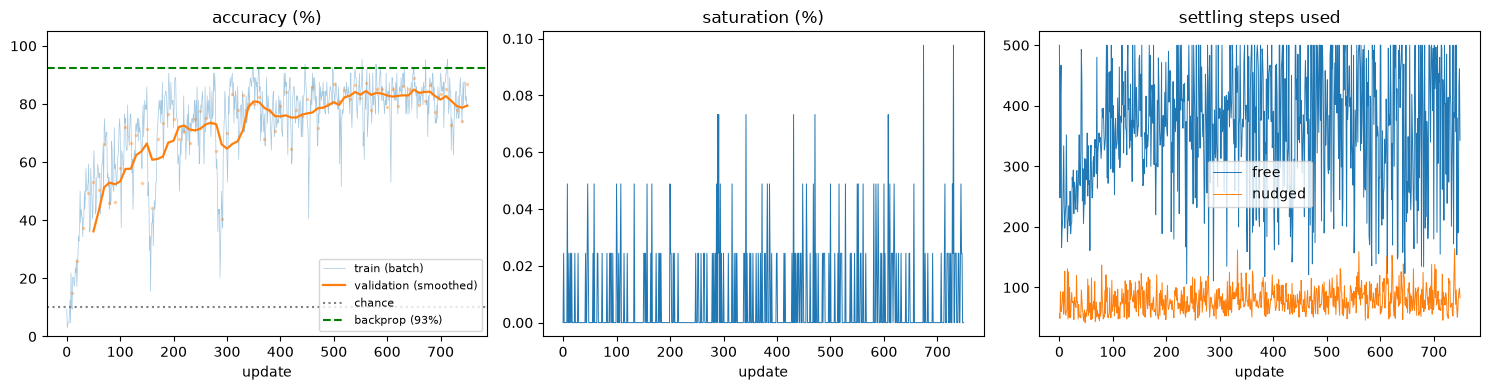

best validation: 89.0% | runtime 552s


In [46]:
# EqProp core — minimal
def ebm_init(in_dim=196, hidden=64, out_dim=10, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    W1 = (torch.randn(in_dim, hidden, generator=g, device=device) / in_dim**0.5).requires_grad_(True)
    W2 = (torch.randn(hidden, out_dim, generator=g, device=device) / hidden**0.5).requires_grad_(True)
    return W1, W2

def ebm_energy(x, h, y, W1, W2):
    state = 0.5 * (h**2).sum() + 0.5 * (y**2).sum()
    align = (h * (x @ W1)).sum() + (y * (torch.tanh(h) @ W2)).sum()
    return state - align

def ebm_settle(x, W1, W2, target=None, beta=0.0, max_steps=1000, dt=0.2,
               patience=10, min_delta=1e-4, h0=None, y0=None):
    """Settle until movement stops improving for `patience` steps (or max_steps)."""
    with torch.enable_grad():
        x = x.reshape(x.size(0), -1)
        h = (torch.zeros(x.size(0), W1.size(1), device=device) if h0 is None else h0.clone()).requires_grad_(True)
        y = (torch.zeros(x.size(0), W2.size(1), device=device) if y0 is None else y0.clone()).requires_grad_(True)
        best_move, since_best, used = float("inf"), 0, max_steps
        for t in range(max_steps):
            gh, gy = torch.autograd.grad(ebm_energy(x, h, y, W1, W2), [h, y])
            if target is not None:
                gy = gy + beta * torch.where(1 - target * y > 0, -target, torch.zeros_like(target))
            move = (dt * (gh.pow(2).sum() + gy.pow(2).sum()).sqrt()).item()
            h.data -= dt * gh; y.data -= dt * gy
            if move < best_move - min_delta: best_move, since_best = move, 0
            else: since_best += 1
            if since_best >= patience: used = t + 1; break
    return h.detach(), y.detach(), used

def ebm_step(x, target, W1, W2, opt, beta=0.5, max_steps=300,  dt=0.1, settle_patience=10):
    x = x.reshape(x.size(0), -1)
    h_f, y_f, sf = ebm_settle(x, W1, W2, max_steps=max_steps, dt=dt, patience=settle_patience)
    h_n, y_n, sn = ebm_settle(x, W1, W2, target, beta, max_steps, dt, h0=h_f, y0=y_f, patience=settle_patience)
    opt.zero_grad()
    gW1_f, gW2_f = torch.autograd.grad(ebm_energy(x, h_f, y_f, W1, W2), [W1, W2])
    gW1_n, gW2_n = torch.autograd.grad(ebm_energy(x, h_n, y_n, W1, W2), [W1, W2])
    W1.grad = (gW1_n - gW1_f) / (beta * x.size(0)); W2.grad = (gW2_n - gW2_f) / (beta * x.size(0))
    opt.step()
    acc = (y_f.argmax(1) == target.argmax(1)).float().mean().item()          # TRAIN batch acc (diagnostic only)
    sat = (torch.tanh(h_f).abs() > 0.95).float().mean().item() * 100
    return acc, sat, sf, sn

# ----- NEW: the honest metric — free-phase accuracy on held-out data -----
def ebm_eval(W1, W2, dataset, n=1000, dt=0.1, max_steps=300, batch=256, settle_patience=10):
    correct = total = 0
    for x, y in DataLoader(Subset(dataset, range(min(n, len(dataset)))), batch_size=batch):
        x, y = x.to(device), y.to(device)
        _, y_hat, _ = ebm_settle(x, W1, W2, max_steps=max_steps, dt=dt, patience=settle_patience)   # free phase, no target
        correct += (y_hat.argmax(1) == y).sum().item(); total += y.size(0)
    return correct / total

def ebm_train(hidden=64, lr=0.1, beta=0.5, max_steps=300, dt=0.1, epochs=3,
              data=train_14, val_data=test_14, batch_size=64, seed=0,
              eval_every=20, val_n=1000, patience=20, settle_patience=10):
    """Logs train acc/step and validation acc every `eval_every` steps.
       Keeps the BEST-validation weights and returns those (handles peak-then-degrade)."""
    W1, W2 = ebm_init(in_dim=196, hidden=hidden, seed=seed)
    opt = torch.optim.SGD([W1, W2], lr=lr)
    loader = DataLoader(data, batch_size=batch_size, shuffle=True)
    steps_per_epoch = len(loader)
    hist = {"train_acc": [], "sat": [], "steps_f": [], "steps_n": [], "val_acc": [], "val_step": []}
    best_val, best_W, since_best = 0.0, None, 0
    step, t0 = 0, time.time()
    for ep in range(epochs):
        for bi, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            target = torch.full((x.size(0), 10), -1.0, device=device); target.scatter_(1, y.unsqueeze(1), 1.0)
            acc, sat, sf, sn = ebm_step(x, target, W1, W2, opt, beta=beta, max_steps=max_steps, dt=dt, settle_patience=settle_patience)
            hist["train_acc"].append(acc); hist["sat"].append(sat)
            hist["steps_f"].append(sf);   hist["steps_n"].append(sn)
            step += 1
            if step % eval_every == 0:
                va = ebm_eval(W1, W2, val_data, n=val_n, dt=dt, max_steps=max_steps)
                hist["val_acc"].append(va); hist["val_step"].append(step)
                if va > best_val:
                    best_val = va; best_W = (W1.detach().clone(), W2.detach().clone()); since_best = 0
                else:
                    since_best += 1                    # count checks with no new best
                if patience and since_best >= patience:
                    print(f"early stop: no new best for {patience} checks (best {best_val*100:.1f}%)")
                    hist["runtime"], hist["best_val"], hist["steps_per_epoch"] = time.time()-t0, best_val, steps_per_epoch
                    return best_W, hist
                print(f"epoch {ep} batch {bi:4d} (step {step:5d}, {time.time()-t0:4.0f}s): "
                      f"train {acc*100:5.1f}% | val {va*100:5.1f}% | best {best_val*100:5.1f}% | sat {sat:4.1f}% | "
                      f"N-free {np.mean(hist['steps_f']):.1f}, N-nudge {np.mean(hist['steps_n']):.1f}")
    hist["runtime"], hist["best_val"], hist["steps_per_epoch"] = time.time() - t0, best_val, steps_per_epoch
    return best_W, hist                                                       # returns BEST weights, not final

def plot_run(hist, target_acc=None):
    e = hist["steps_per_epoch"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot([a*100 for a in hist["train_acc"]], lw=0.5, alpha=0.4, label="train (batch)")
    # in plot_run, replace the validation line with raw + smoothed
    v = np.array(hist["val_acc"]) * 100
    ax[0].plot(hist["val_step"], v, ".", ms=3, alpha=0.3, color="tab:orange")
    if len(v) >= 5:
        k = 5; vs = np.convolve(v, np.ones(k)/k, "valid")
        ax[0].plot(hist["val_step"][k-1:], vs, "-", lw=1.6, color="tab:orange", label="validation (smoothed)")
    ax[0].axhline(10, color="gray", ls=":", label="chance")
    if target_acc: ax[0].axhline(target_acc, color="green", ls="--", label=f"backprop ({target_acc:.0f}%)")
    ax[0].set_ylim(0, 105); ax[0].legend(fontsize=8); ax[0].set_title("accuracy (%)")
    ax[1].plot(hist["sat"], lw=0.7); ax[1].set_title("saturation (%)")
    ax[2].plot(hist["steps_f"], lw=0.7, label="free"); ax[2].plot(hist["steps_n"], lw=0.7, label="nudged")
    ax[2].legend(); ax[2].set_title("settling steps used")
    for a in ax:
        a.set_xlabel("update")
        for k in range(1, (len(hist["train_acc"]) // e) + 1):                # faint epoch boundaries
            a.axvline(k * e, color="gray", lw=0.5, alpha=0.4)
    plt.tight_layout(); plt.show()

best_W, hist = ebm_train(hidden=64, lr=0.03, beta=0.3, max_steps=500, dt=0.3, epochs=3, eval_every=10, patience=10, settle_patience=30)
plot_run(hist, target_acc=BACKPROP_ACC if "BACKPROP_ACC" in dir() else None)
print(f"best validation: {hist['best_val']*100:.1f}% | runtime {hist['runtime']:.0f}s")

### Settle experiment

* find steps required for equilibrium

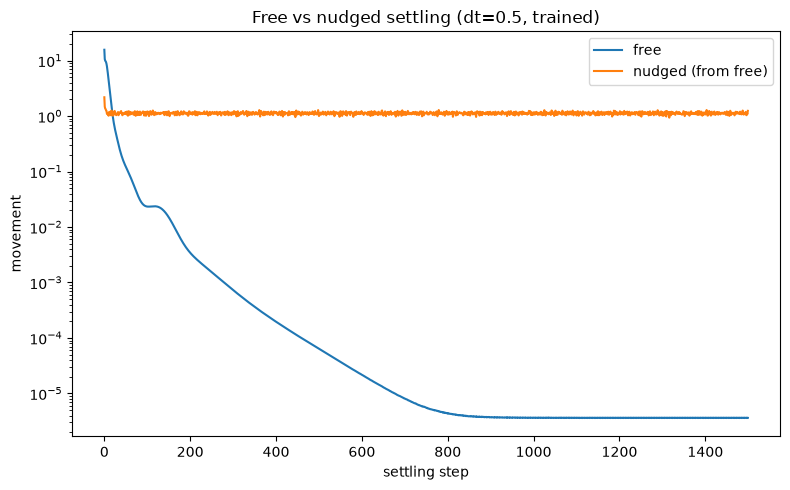

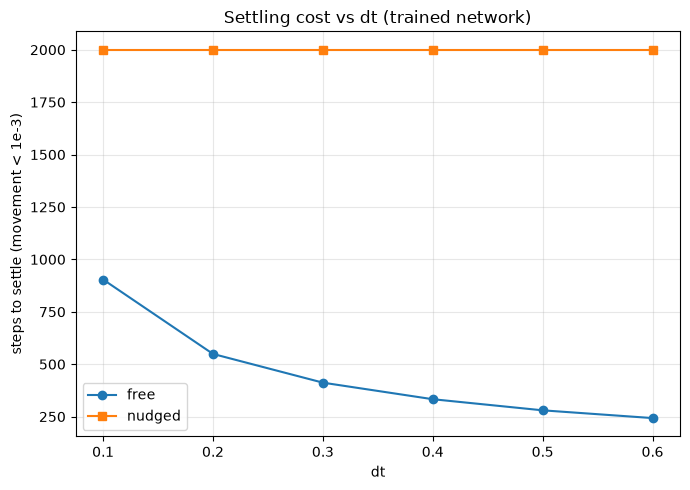

In [47]:
def settle_trace(x, W1, W2, target=None, beta=0.5, dt=0.5, steps=1500, h0=None, y0=None):
    """Per-step movement during settling. target=None -> free phase; else nudged. Returns moves, final (h,y)."""
    x = x.reshape(x.size(0), -1)
    h = (torch.zeros(x.size(0), W1.size(1), device=device) if h0 is None else h0.clone()).requires_grad_(True)
    y = (torch.zeros(x.size(0), W2.size(1), device=device) if y0 is None else y0.clone()).requires_grad_(True)
    moves = []
    with torch.enable_grad():
        for _ in range(steps):
            gh, gy = torch.autograd.grad(ebm_energy(x, h, y, W1, W2), [h, y])
            if target is not None:
                gy = gy + beta * torch.where(1 - target * y > 0, -target, torch.zeros_like(target))
            moves.append((dt * (gh.pow(2).sum() + gy.pow(2).sum()).sqrt()).item())
            h.data -= dt * gh; y.data -= dt * gy
    return moves, (h.detach(), y.detach())

# fixed batch (reproducible) + its targets
g = torch.Generator().manual_seed(0)
xb, yb = next(iter(DataLoader(train_14, batch_size=128, shuffle=True, generator=g)))
xb, yb = xb.to(device), yb.to(device)
tgt = torch.full((xb.size(0), 10), -1.0, device=device); tgt.scatter_(1, yb.unsqueeze(1), 1.0)
W1, W2 = best_W                                            # trained weights from your run

# (a) both phases at one dt
fm, (hf, yf) = settle_trace(xb, W1, W2, dt=0.5, steps=1500)
nm, _        = settle_trace(xb, W1, W2, target=tgt, beta=0.5, dt=0.5, steps=1500, h0=hf, y0=yf)  # nudged warm-starts from free
plt.figure(figsize=(8, 5))
plt.plot(fm, label="free"); plt.plot(nm, label="nudged (from free)")
plt.yscale("log"); plt.xlabel("settling step"); plt.ylabel("movement"); plt.legend()
plt.title("Free vs nudged settling (dt=0.5, trained)"); plt.tight_layout(); plt.show()

# (b) the relationship: steps-to-settle vs dt, for both phases
def steps_to_settle(moves, floor=1e-3):
    for i, m in enumerate(moves):
        if m < floor: return i + 1
    return len(moves)                                     # never settled within the budget

dts, free_s, nud_s = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6], [], []
for dt in dts:
    fm, (hf, yf) = settle_trace(xb, W1, W2, dt=dt, steps=2000)
    nm, _        = settle_trace(xb, W1, W2, target=tgt, beta=0.5, dt=dt, steps=2000, h0=hf, y0=yf)
    free_s.append(steps_to_settle(fm)); nud_s.append(steps_to_settle(nm))
plt.figure(figsize=(7, 5))
plt.plot(dts, free_s, "o-", label="free"); plt.plot(dts, nud_s, "s-", label="nudged")
plt.xlabel("dt"); plt.ylabel("steps to settle (movement < 1e-3)"); plt.legend()
plt.title("Settling cost vs dt (trained network)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Batch size

* does it make a difference to accuracy?
* does it train faster?
* FUTURE separate test on single batch training - more biological

epoch 0 batch   19 (step    20,    3s): train  18.8% | val   8.9% | best   8.9% | sat  0.7%
epoch 0 batch   39 (step    40,    6s): train  37.5% | val  11.0% | best  11.0% | sat  0.2%
epoch 0 batch   59 (step    60,   10s): train  56.2% | val  44.2% | best  44.2% | sat  0.1%
epoch 0 batch   79 (step    80,   13s): train  43.8% | val  47.0% | best  47.0% | sat  0.2%
epoch 0 batch   99 (step   100,   17s): train  25.0% | val  23.2% | best  47.0% | sat  0.3%
epoch 0 batch  119 (step   120,   20s): train  56.2% | val  51.4% | best  51.4% | sat  0.3%
epoch 0 batch  139 (step   140,   24s): train  68.8% | val  55.7% | best  55.7% | sat  0.4%
epoch 0 batch  159 (step   160,   28s): train  56.2% | val  64.2% | best  64.2% | sat  0.0%
epoch 0 batch  179 (step   180,   32s): train  68.8% | val  46.7% | best  64.2% | sat  0.4%
epoch 0 batch  199 (step   200,   36s): train  43.8% | val  62.5% | best  64.2% | sat  0.3%
epoch 0 batch  219 (step   220,   40s): train  31.2% | val  27.7% | best  64.2% 

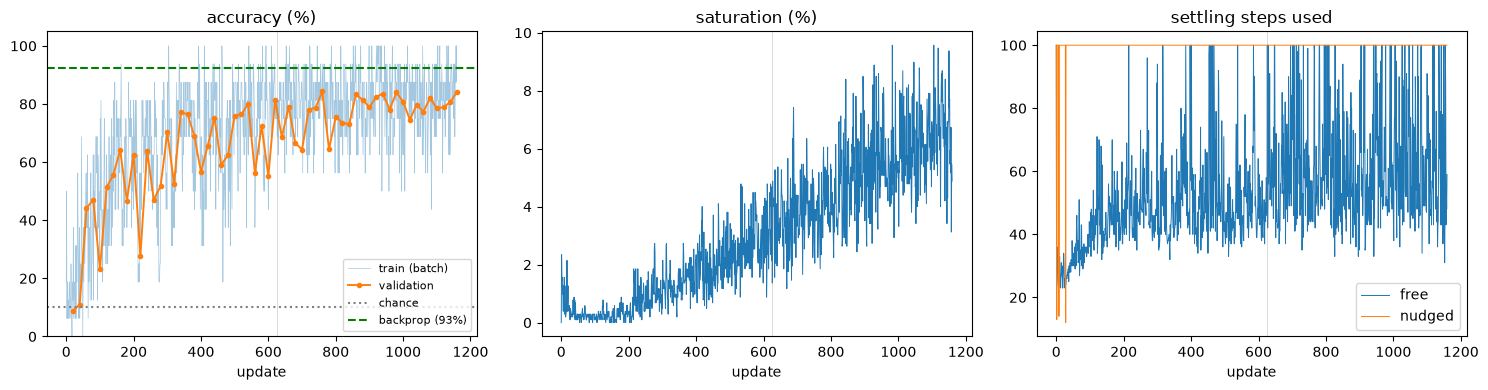

epoch 0 batch   19 (step    20,    4s): train  12.5% | val  15.8% | best  15.8% | sat  0.0%
epoch 0 batch   39 (step    40,    8s): train   9.4% | val  28.9% | best  28.9% | sat  0.0%
epoch 0 batch   59 (step    60,   13s): train  31.2% | val  47.1% | best  47.1% | sat  0.0%
epoch 0 batch   79 (step    80,   17s): train  56.2% | val  45.0% | best  47.1% | sat  0.0%
epoch 0 batch   99 (step   100,   22s): train  25.0% | val  20.9% | best  47.1% | sat  0.1%
epoch 0 batch  119 (step   120,   26s): train  68.8% | val  66.9% | best  66.9% | sat  0.2%
epoch 0 batch  139 (step   140,   31s): train  40.6% | val  27.2% | best  66.9% | sat  0.3%
epoch 0 batch  159 (step   160,   36s): train  75.0% | val  61.5% | best  66.9% | sat  0.2%
epoch 0 batch  179 (step   180,   41s): train  68.8% | val  50.5% | best  66.9% | sat  0.4%
epoch 0 batch  199 (step   200,   46s): train  50.0% | val  64.2% | best  66.9% | sat  0.0%
epoch 0 batch  219 (step   220,   51s): train  84.4% | val  70.8% | best  70.8% 

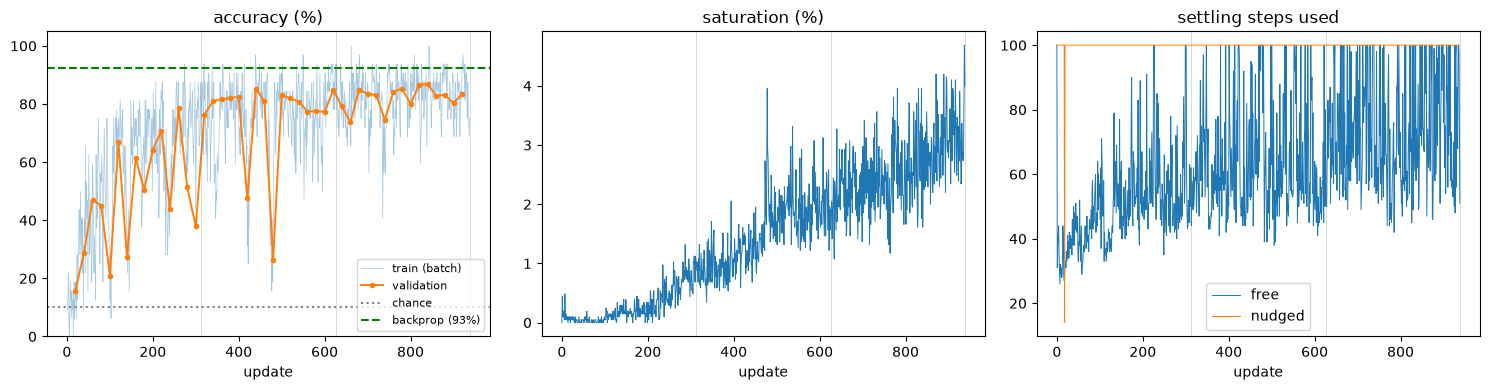

epoch 0 batch   19 (step    20,    4s): train  25.0% | val  11.2% | best  11.2% | sat  0.0%
epoch 0 batch   39 (step    40,    8s): train  34.4% | val  28.0% | best  28.0% | sat  0.1%
epoch 0 batch   59 (step    60,   12s): train  26.6% | val  48.7% | best  48.7% | sat  0.1%
epoch 0 batch   79 (step    80,   16s): train  48.4% | val  55.3% | best  55.3% | sat  0.1%
epoch 0 batch   99 (step   100,   20s): train  75.0% | val  68.2% | best  68.2% | sat  0.0%
epoch 0 batch  119 (step   120,   25s): train  51.6% | val  64.9% | best  68.2% | sat  0.0%
epoch 0 batch  139 (step   140,   29s): train  78.1% | val  72.2% | best  72.2% | sat  0.0%
epoch 1 batch    2 (step   160,   33s): train  60.9% | val  50.6% | best  72.2% | sat  0.2%
epoch 1 batch   22 (step   180,   37s): train  82.8% | val  78.6% | best  78.6% | sat  0.1%
epoch 1 batch   42 (step   200,   42s): train  57.8% | val  52.0% | best  78.6% | sat  0.0%
epoch 1 batch   62 (step   220,   47s): train  84.4% | val  77.6% | best  78.6% 

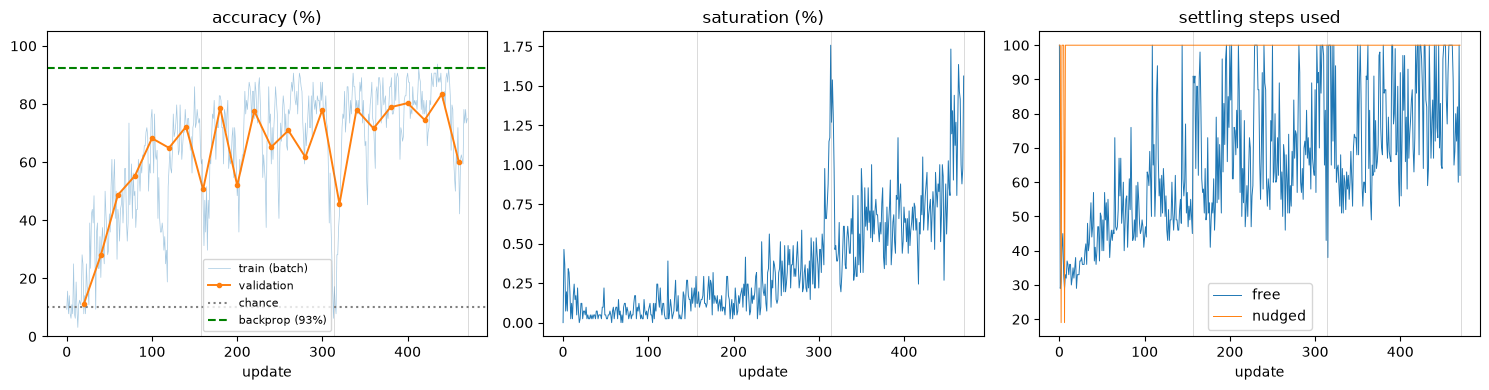

epoch 0 batch   19 (step    20,    4s): train  27.3% | val  19.0% | best  19.0% | sat  0.1%
epoch 0 batch   39 (step    40,    9s): train  52.3% | val  49.2% | best  49.2% | sat  0.1%
epoch 0 batch   59 (step    60,   14s): train  44.5% | val  54.0% | best  54.0% | sat  0.0%
epoch 1 batch    0 (step    80,   19s): train  19.5% | val  16.0% | best  54.0% | sat  0.1%
epoch 1 batch   20 (step   100,   23s): train  75.8% | val  71.4% | best  71.4% | sat  0.3%
epoch 1 batch   40 (step   120,   27s): train  53.9% | val  51.3% | best  71.4% | sat  0.4%
epoch 1 batch   60 (step   140,   32s): train  68.8% | val  70.3% | best  71.4% | sat  0.3%
epoch 2 batch    1 (step   160,   37s): train  14.1% | val  39.5% | best  71.4% | sat  0.4%
epoch 2 batch   21 (step   180,   43s): train  78.1% | val  68.1% | best  71.4% | sat  0.3%
epoch 2 batch   41 (step   200,   48s): train  62.5% | val  55.2% | best  71.4% | sat  0.5%
epoch 2 batch   61 (step   220,   53s): train  61.7% | val  63.4% | best  71.4% 

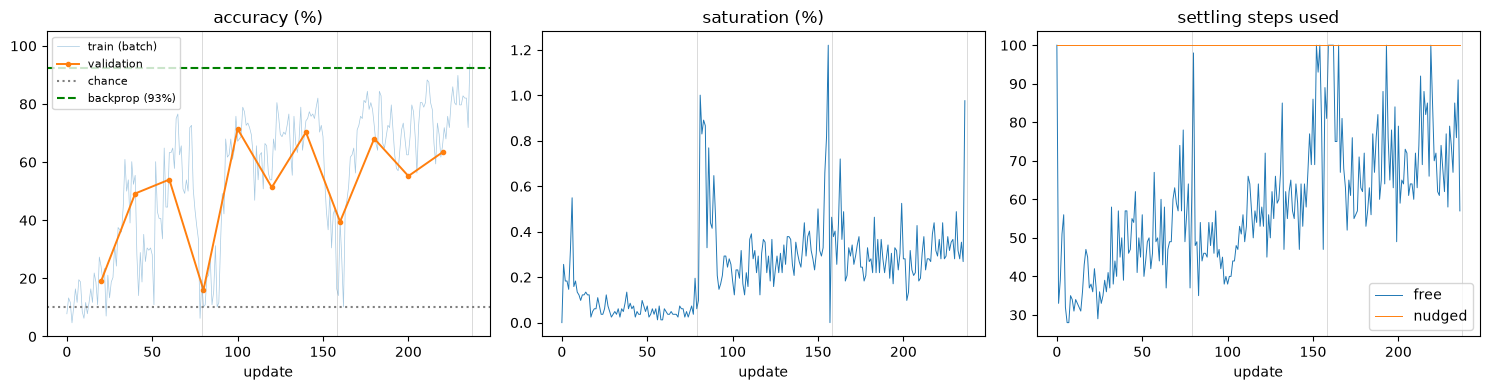

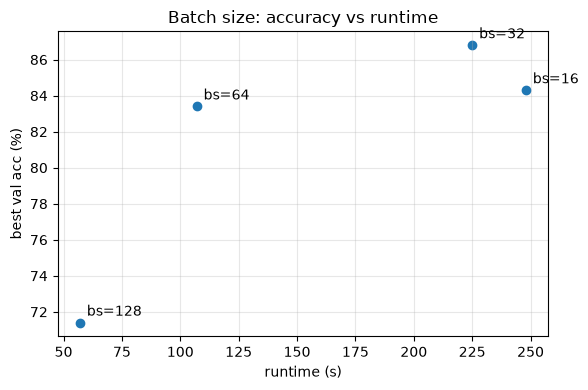

,batch_size,val_acc,runtime_s
0,16,84.3,248
1,32,86.8,225
2,64,83.4,107
3,128,71.4,57


In [27]:
rows = []
for bs in [16, 32, 64, 128]:
    bW, h = ebm_train(batch_size=bs, hidden=64, lr=0.1, beta=0.5, dt=0.5, max_steps=100, tol=1e-2,
                      epochs=3, data=Subset(train_14, range(10000)), eval_every=20)
    plot_run(h, target_acc=BACKPROP_ACC)                              # diagnostics per run, as you asked
    rows.append({"batch_size": bs, "val_acc": h["best_val"]*100, "runtime_s": round(h["runtime"])})
df = pd.DataFrame(rows)

plt.figure(figsize=(6, 4))
plt.scatter(df["runtime_s"], df["val_acc"])
for _, r in df.iterrows(): plt.annotate(f"bs={int(r.batch_size)}", (r.runtime_s, r.val_acc),
                                        textcoords="offset points", xytext=(5, 5))
plt.xlabel("runtime (s)"); plt.ylabel("best val acc (%)"); plt.title("Batch size: accuracy vs runtime")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
df

### Hyperparameter grid search

* Coarse grid over hyperparameters hidden, lr, beta, dt
* Observe steps, accuracy, runtime.
* Intended to map out and understand relationships

In [ ]:
import itertools

def grid_search(params):
    grid = {
        "hidden": [64],
        "lr": [0.1],
        "dt": [0.3],
        "beta": [0.3],
        "batch_size": [256],
        "tol": [1e-2],
        "max_steps": [200],
        # "epochs": [5]
    }
    grid.update(params)
    results = []
    for combo in itertools.product(*grid.values()):
        # print(grid)
        # param_str = ", ".join([f"{key}: {value}" for key, value in combo.items()])
        
        cfg = dict(zip(grid, combo))
        
        print(cfg)
        
        (W1, W2), hist = ebm_train(**cfg, epochs=3, data=Subset(train_14, range(10000)))
        results.append({**cfg, **hist})
        
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        ax[0].plot([a*100 for a in hist["acc"]], lw=0.7); ax[0].axhline(10, color="gray", ls=":"); ax[0].set_title("accuracy (%)")
        ax[1].plot(hist["sat"], lw=0.7); ax[1].set_title("saturation (%)")
        ax[2].plot(hist["steps_f"], lw=0.7, label="free"); ax[2].plot(hist["steps_n"], lw=0.7, label="nudged")
        ax[2].legend(); ax[2].set_title(f"{cfg}")
        for a in ax: a.set_xlabel("update")
        plt.tight_layout(); plt.show()

    return results

all_results = {}

In [ ]:
 
params = {
    # "hidden": [32, 64, 128],
    "lr": [0.02, 0.05, 0.1, 0.2, 0.3],
    # "dt": [0.1, 0.2, 0.3, 0.5],
    # "beta": [0.1, 0.2, 0.3, 0.5],
    # "batch_size": [32, 128, 256, 512],
    # "tol": [1e-1, 1e-2, 1e-3],
    # "max_steps": [50, 100, 200, 400],
}
all_results['0_lr'] = grid_search(params)

### Catastrophic Forgetting

#### Set up data

In [53]:
# one task per digit; per-class indices at 14×14
train_idx = {c: (train_14.targets == c).nonzero(as_tuple=True)[0] for c in range(10)}
test_idx  = {c: (test_14.targets  == c).nonzero(as_tuple=True)[0] for c in range(10)}

# fixed eval set: 100 test images per class, stacked once (fast repeated evaluation)
N_EVAL = 100
eval_x = torch.cat([torch.stack([test_14[i][0] for i in test_idx[c][:N_EVAL]]) for c in range(10)]).to(device)
eval_y = torch.cat([torch.full((N_EVAL,), c) for c in range(10)]).to(device)


@torch.no_grad()
def per_class_bp(model):
    pred = model(eval_x).argmax(1)
    return [(pred[eval_y == c] == c).float().mean().item() for c in range(10)]

def per_class_ebm(W1, W2, dt=0.5, max_steps=80):
    _, y, _ = ebm_settle(eval_x, W1, W2, max_steps=max_steps, dt=dt)   # one free-phase settle for all 1000
    pred = y.argmax(1)
    return [(pred[eval_y == c] == c).float().mean().item() for c in range(10)]

def run_classil_backprop(iters_per_task=100, lr=0.1, batch_size=64, eval_every=1, seed=0):
    torch.manual_seed(seed)
    model = make_mlp(hidden=(64,), in_dim=196).to(device)
    opt, lf = torch.optim.SGD(model.parameters(), lr=lr), nn.CrossEntropyLoss()
    hist = {"step": [], "acc": []}; step = 0
    for c in range(10):                                              # sequential tasks
        loader = DataLoader(Subset(train_14, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); lf(model(x), y).backward(); opt.step(); step += 1
            if step % eval_every == 0:
                hist["step"].append(step); hist["acc"].append(per_class_bp(model))
    return model, hist

def run_classil_ebm(iters_per_task=100, lr=0.1, beta=0.5, dt=0.5, max_steps=80,
                    batch_size=64, eval_every=1, seed=0):
    W1, W2 = ebm_init(in_dim=196, hidden=64, seed=seed)
    opt = torch.optim.SGD([W1, W2], lr=lr)
    hist = {"step": [], "acc": []}; step = 0
    for c in range(10):
        loader = DataLoader(Subset(train_14, train_idx[c].tolist()), batch_size=batch_size, shuffle=True)
        it = iter(loader)
        for _ in range(iters_per_task):
            try: x, y = next(it)
            except StopIteration: it = iter(loader); x, y = next(it)
            x, y = x.to(device), y.to(device)
            target = torch.full((x.size(0), 10), -1.0, device=device); target.scatter_(1, y.unsqueeze(1), 1.0)
            ebm_step(x, target, W1, W2, opt, beta=beta, dt=dt, max_steps=max_steps); step += 1
            if step % eval_every == 0:
                hist["step"].append(step); hist["acc"].append(per_class_ebm(W1, W2, dt=dt, max_steps=max_steps))
    return (W1, W2), hist


def plot_classil(hist, iters_per_task, title):
    steps, A = hist["step"], np.array(hist["acc"]) * 100          # A: [n_eval, 10]
    colors = plt.cm.tab10(np.arange(10))
    plt.figure(figsize=(12, 5))
    for c in range(10):
        plt.plot(steps, A[:, c], color=colors[c], lw=1, alpha=0.7, label=f"digit {c}")
    plt.plot(steps, A.mean(1), "k-", lw=2.5, label="mean (all classes)")
    for c in range(11): plt.axvline(c * iters_per_task, color="gray", lw=0.5, alpha=0.4)
    plt.axhline(10, color="gray", ls=":", lw=1)
    plt.xlabel("training step"); plt.ylabel("test accuracy (%)"); plt.ylim(0, 105)
    plt.title(title); plt.legend(ncol=2, fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

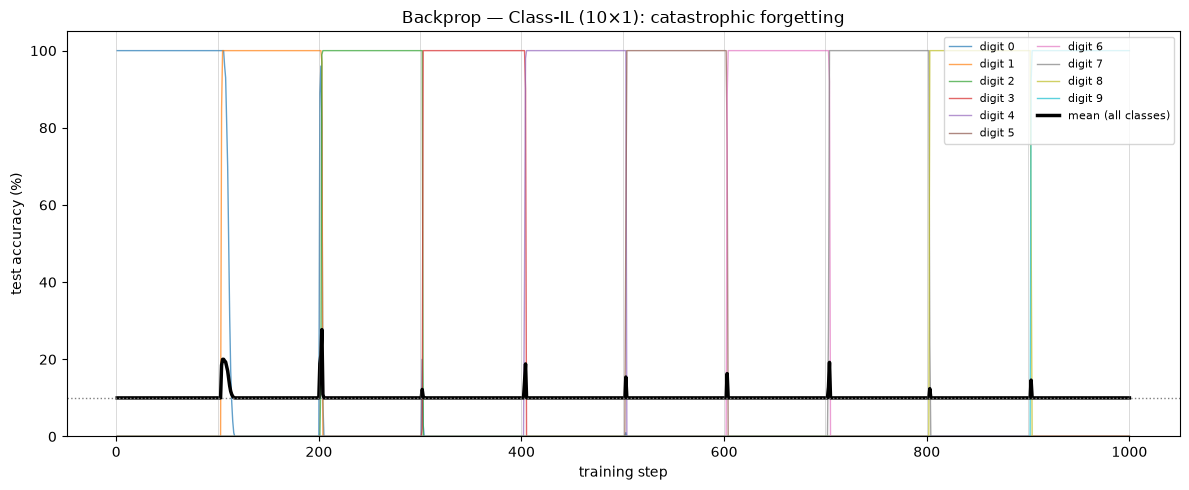

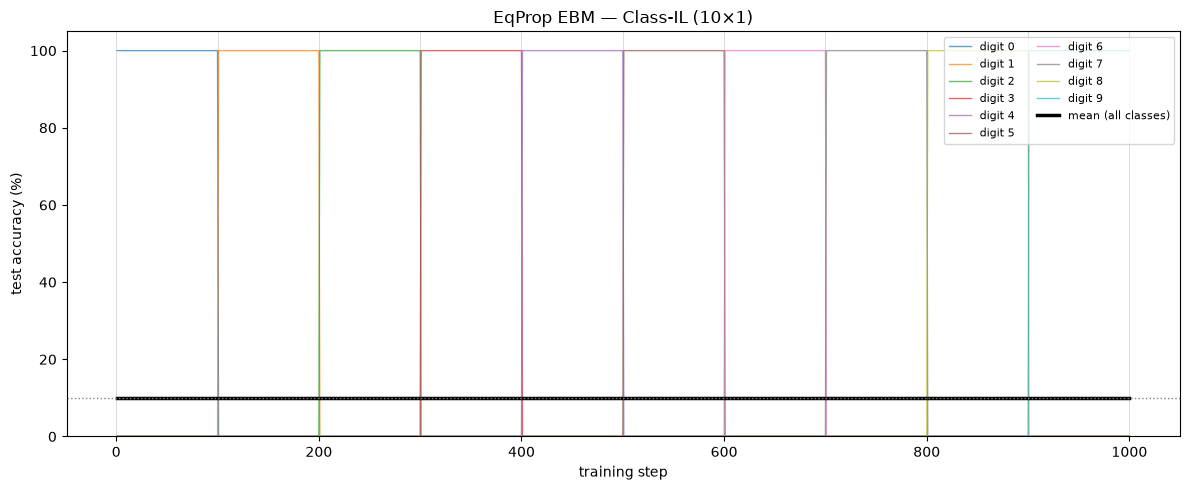

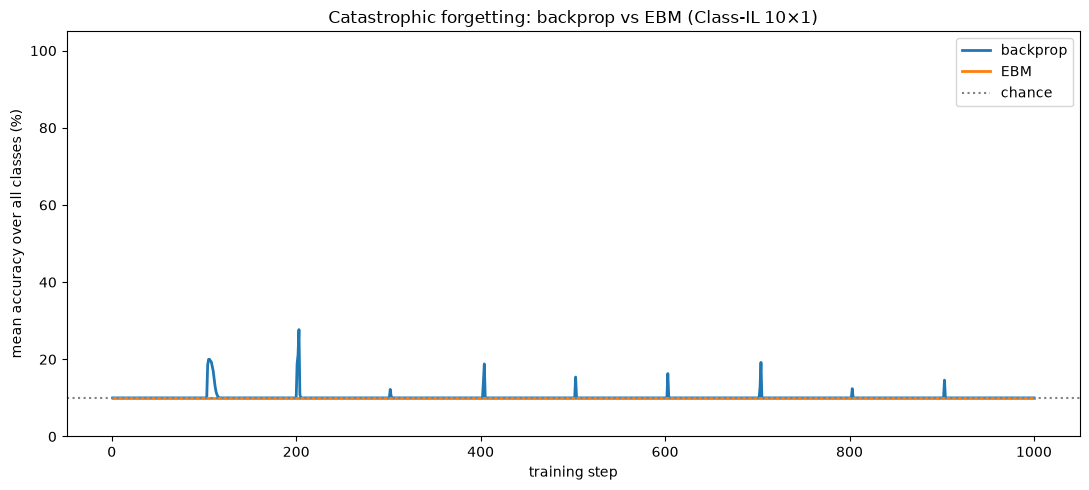

In [54]:
ITERS = 100
model_bp, hist_bp = run_classil_backprop(iters_per_task=ITERS)
plot_classil(hist_bp, ITERS, "Backprop — Class-IL (10×1): catastrophic forgetting")

(W1e, W2e), hist_ebm = run_classil_ebm(iters_per_task=ITERS)
plot_classil(hist_ebm, ITERS, "EqProp EBM — Class-IL (10×1)")

# the answer to your question: do the two mean-accuracy curves differ?
plt.figure(figsize=(11, 5))
plt.plot(hist_bp["step"],  np.array(hist_bp["acc"]).mean(1)*100,  lw=2, label="backprop")
plt.plot(hist_ebm["step"], np.array(hist_ebm["acc"]).mean(1)*100, lw=2, label="EBM")
plt.axhline(10, color="gray", ls=":", label="chance")
plt.xlabel("training step"); plt.ylabel("mean accuracy over all classes (%)"); plt.ylim(0, 105)
plt.title("Catastrophic forgetting: backprop vs EBM (Class-IL 10×1)"); plt.legend(); plt.tight_layout(); plt.show()